In [ ]:
#Import Library
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans' | Random state: 42


In [ ]:
# Load data
df_raw = pd.read_csv('/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()

Data awal: 253680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [ ]:
# Preprocessing
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus ke diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")  # laporan jumlah baris setelah kelas 1 dibuang

# Membuang kolom income
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Menghapus baris duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

# Rapikan nomor baris jadi 0,1,2,... lagi
df = df.reset_index(drop=True)

# Pisahkan tabel fitur dan label
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Bentuk data siap klaster: {X_scaled.shape}")
print(f"Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
df_features.head()

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek mean 0 dan std 1: -0.0000 / 1.0000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0


In [ ]:
# Class Kmeans
class KMeansManhattan:
    """K-Means dengan jarak Manhattan (L1). Centroid diupdate pakai median per dimensi."""
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='manhattan', n_jobs=-1)

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.median(cluster_pts, axis=0)
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansManhattan berhasil diinisialisasi.")

[INFO] Kelas KMeansManhattan berhasil diinisialisasi.


  k = 1  | SAE = 2,484,011.4 | iterasi = 2
  k = 2  | SAE = 2,125,202.0 | iterasi = 7
  k = 3  | SAE = 2,113,633.7 | iterasi = 4
  k = 4  | SAE = 1,952,558.7 | iterasi = 4
  k = 5  | SAE = 1,920,561.9 | iterasi = 4
  k = 6  | SAE = 1,898,823.7 | iterasi = 6
  k = 7  | SAE = 1,845,771.2 | iterasi = 9
  k = 8  | SAE = 1,797,568.1 | iterasi = 9
  k = 9  | SAE = 1,785,210.4 | iterasi = 4
  k = 10 | SAE = 1,772,815.5 | iterasi = 7
[ELBOW] Jumlah klaster optimal terdeteksi: k = 4
[SIMPAN] Grafik Elbow disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/elbow_manhattan.png'


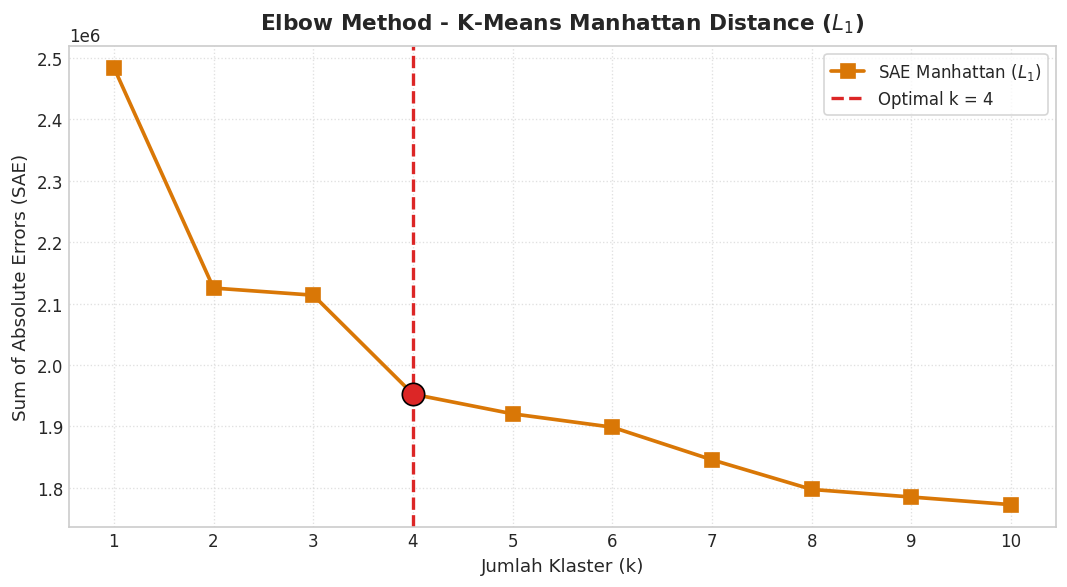

In [ ]:
# Elbow Manhattan
k_range = list(range(1, 11))
sae_manhattan = []

for k in k_range:
    km = KMeansManhattan(n_clusters=k, max_iter=200, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sae_manhattan.append(km.inertia_)
    print(f"  k = {k:<2} | SAE = {km.inertia_:,.1f} | iterasi = {km.n_iter_}")

def find_elbow_point(k_vals, inertias):
    p1 = np.array([k_vals[0], inertias[0]])
    p2 = np.array([k_vals[-1], inertias[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [
        np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit)
        for k, s in zip(k_vals, inertias)
    ]
    return k_vals[int(np.argmax(dists))]

optimal_k = find_elbow_point(k_range, sae_manhattan)
print(f"[ELBOW] Jumlah klaster optimal terdeteksi: k = {optimal_k}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, sae_manhattan, marker='s', markersize=8, linewidth=2.2, color='#D97706', label='SAE Manhattan ($L_1$)')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [sae_manhattan[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')
plt.title('Elbow Method - K-Means Manhattan Distance ($L_1$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Sum of Absolute Errors (SAE)', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_manhattan.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [ ]:
# Klastering Final
model_manhattan = KMeansManhattan(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_manhattan.fit(X_scaled)
labels = model_manhattan.labels_

sil_score = float(silhouette_score(X_scaled, labels, metric='manhattan', sample_size=10000, random_state=RANDOM_STATE))
db_score = float(davies_bouldin_score(X_scaled, labels))  # Davies-Bouldin (makin kecil makin bagus)
ch_score = float(calinski_harabasz_score(X_scaled, labels))  # Calinski-Harabasz (makin besar makin bagus)

eval_df = pd.DataFrame([{
    'Distance Metric': 'Manhattan Distance (L1)',
    'Optimal k': optimal_k,
    'Jumlah Data': X_scaled.shape[0],
    'Jumlah Fitur': X_scaled.shape[1],
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_manhattan.execution_time_, 5),
    'Iterations (↓)': model_manhattan.n_iter_,
    'Objective Value (SAE) (↓)': round(model_manhattan.inertia_, 2)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI K-MEANS MANHATTAN")
print("=" * 80)
print(eval_df.to_string(index=False))
print("=" * 80)

df_clustered = df_features.copy()
df_clustered['Diabetes_012'] = y_label.values  # tambah label asli
df_clustered['Cluster_Manhattan'] = labels  # tambah label klaster

profil = df_clustered.groupby('Cluster_Manhattan').mean().round(3)  # rata-rata tiap fitur per klaster
profil['Jumlah Data'] = df_clustered['Cluster_Manhattan'].value_counts().sort_index()  # jumlah anggota klaster
profil['% Diabetes'] = (df_clustered.groupby('Cluster_Manhattan')['Diabetes_012'].apply(lambda s: (s == 2).mean() * 100)).round(2)  # persen diabetes per klaster

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_manhattan.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)  # sheet 1: evaluasi
    profil.to_excel(writer, sheet_name='Profil_Klaster')  # sheet 2: profil klaster
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_manhattan.csv")
df_clustered.to_csv(csv_path, index=False)  # simpan data + label klaster (CSV lebih ringan)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")




TABEL EVALUASI K-MEANS MANHATTAN
        Distance Metric  Optimal k  Jumlah Data  Jumlah Fitur  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SAE) (↓)
Manhattan Distance (L1)          4       208858            20                0.1299                    2.9811                     12961.67                 0.71653               4                 1952558.69
[SIMPAN] Evaluasi & profil klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/evaluasi_kmeans_manhattan.xlsx'
[SIMPAN] Data terklaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/data_terklaster_manhattan.csv'


In [ ]:
# Profil Tiap Klaster
profil

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,Jumlah Data,% Diabetes
Cluster_Manhattan,,,,,,,,,,,,,,,,,,,,,
0,0.227,0.246,0.948,27.295,0.298,0.022,0.042,0.822,0.757,0.841,...,2.197,2.874,2.512,0.066,0.287,7.410,5.286,0.151,98975,7.55
1,0.172,0.164,0.866,28.602,0.358,0.016,0.033,0.721,0.372,0.714,...,2.417,3.583,2.594,0.066,0.685,5.400,4.345,0.136,12000,6.78
2,0.760,0.672,0.983,31.455,0.634,0.127,0.250,0.319,0.660,0.736,...,3.864,8.163,17.091,0.829,0.255,9.560,4.408,0.709,32579,35.43
3,0.721,0.689,0.973,29.904,0.681,0.053,0.153,0.761,0.373,0.736,...,2.757,2.884,3.144,0.105,0.723,8.748,4.861,0.453,65304,22.63


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans/cluster_manhattan.png'


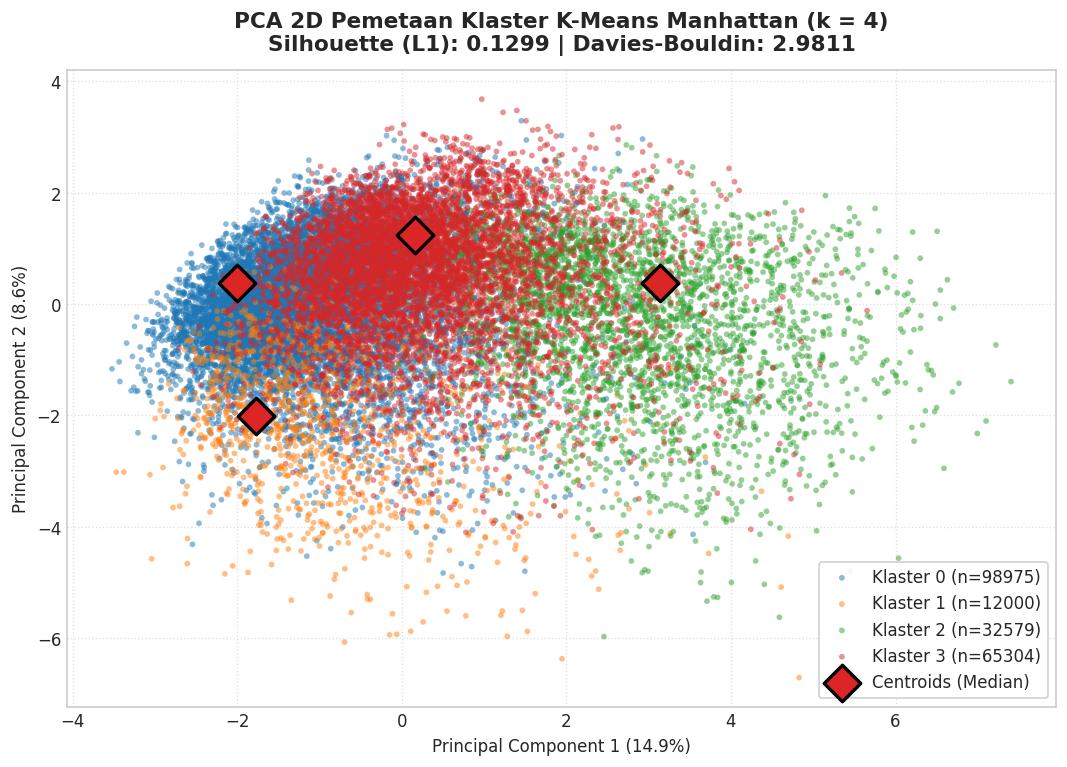

In [ ]:
# Visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)  # PCA ke 2 dimensi
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_manhattan.centroids)  # proyeksikan centroid ke ruang 2D yang sama

rng_plot = np.random.RandomState(RANDOM_STATE)
n_plot = min(20000, len(X_pca))  # gambar maksimal 20.000 titik biar ringan
idx_plot = rng_plot.choice(len(X_pca), size=n_plot, replace=False)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (labels[idx_plot] == k)  # titik sampel yang masuk klaster k
    plt.scatter(
        X_pca[idx_plot][mask, 0], X_pca[idx_plot][mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(labels == k)})',
        alpha=0.5, s=12, edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='D', s=240, c='#DC2626',
    edgecolor='black', linewidth=2,
    label='Centroids (Median)', zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Manhattan (k = {optimal_k})\n'
          f'Silhouette (L1): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_manhattan.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

In [ ]:
# Fitur paling berpengaruh
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])  # bobot fitur di tiap PC
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))  # 6 teratas PC1
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))  # 6 teratas PC2

Fitur paling berpengaruh di PC1:
GenHlth                 0.433
DiffWalk                0.397
PhysHlth                0.378
HighBP                  0.290
HeartDiseaseorAttack    0.255
Age                     0.232
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age              0.457
NoDocbcCost      0.393
AnyHealthcare    0.352
MentHlth         0.342
HighBP           0.289
HighChol         0.277
Name: PC2, dtype: float64
